In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["TotalCharges"].dtype

dtype('O')

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df["TotalCharges"].dtype

dtype('float64')

In [10]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [11]:
df = df.dropna(subset=["TotalCharges"])

In [12]:
df.shape

(7032, 21)

In [13]:
df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

In [14]:
import sqlite3

conn = sqlite3.connect("customer_churn.db")

df.to_sql(
    "customer_churn",
    conn,
    if_exists="replace",
    index=False
)

7032

In [15]:
pd.read_sql(
    "SELECT * FROM customer_churn LIMIT 5",
    conn
)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
pd.read_sql("""
SELECT COUNT(*) AS Total_Customers
FROM customer_churn;
""", conn)

,Total_Customers
0,7032


In [17]:
pd.read_sql("""
SELECT
ROUND(
100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn;
""", conn)

,Churn_Rate
0,26.58


In [18]:
pd.read_sql("""
SELECT
Contract,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
ROUND(
100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY Contract
ORDER BY Churn_Rate DESC;
""", conn)

,Contract,Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


In [19]:
pd.read_sql("""
SELECT
PaymentMethod,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
ROUND(
100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY PaymentMethod
ORDER BY Churn_Rate DESC;
""", conn)

,PaymentMethod,Customers,Churned_Customers,Churn_Rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1604,308,19.20
2,Bank transfer (automatic),1542,258,16.73
3,Credit card (automatic),1521,232,15.25


In [20]:
pd.read_sql("""
SELECT
ROUND(SUM(TotalCharges),2) AS Revenue_Lost
FROM customer_churn
WHERE Churn='Yes';
""", conn)

,Revenue_Lost
0,2862926.9


In [21]:
pd.read_sql("""
SELECT
Contract,
ROUND(AVG(MonthlyCharges),2) AS Avg_Monthly_Charges
FROM customer_churn
GROUP BY Contract
ORDER BY Avg_Monthly_Charges DESC;
""", conn)

,Contract,Avg_Monthly_Charges
0,Month-to-month,66.40
1,One year,65.08
2,Two year,60.87


In [22]:
pd.read_sql("""
SELECT
ROUND(AVG(tenure),2) AS Avg_Tenure_Churned
FROM customer_churn
WHERE Churn='Yes';
""", conn)

,Avg_Tenure_Churned
0,17.98


In [23]:
pd.read_sql("""
SELECT
InternetService,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY InternetService
ORDER BY Churn_Rate DESC;
""", conn)

,InternetService,Customers,Churned,Churn_Rate
0,Fiber optic,3096,1297,41.89
1,DSL,2416,459,19.00
2,No,1520,113,7.43


In [24]:
pd.read_sql("""
SELECT
SeniorCitizen,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY SeniorCitizen;
""", conn)

,SeniorCitizen,Customers,Churned,Churn_Rate
0,0,5890,1393,23.65
1,1,1142,476,41.68


In [25]:
pd.read_sql("""
SELECT
gender,
COUNT(*) AS Customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY gender;
""", conn)

,gender,Customers,Churned,Churn_Rate
0,Female,3483,939,26.96
1,Male,3549,930,26.20


In [26]:
pd.read_sql("""
WITH ContractStats AS (
SELECT
Contract,
ROUND(
100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2
) AS Churn_Rate
FROM customer_churn
GROUP BY Contract
)
SELECT *,
RANK() OVER(ORDER BY Churn_Rate DESC) AS Churn_Rank
FROM ContractStats;
""", conn)

,Contract,Churn_Rate,Churn_Rank
0,Month-to-month,42.71,1
1,One year,11.28,2
2,Two year,2.85,3


In [27]:
pd.read_sql("""
SELECT
customerID,
Contract,
MonthlyCharges,
TotalCharges
FROM customer_churn
WHERE Churn='Yes'
ORDER BY TotalCharges DESC
LIMIT 10;
""", conn)

,customerID,Contract,MonthlyCharges,TotalCharges
0,2889-FPWRM,One year,117.80,8684.80
1,0201-OAMXR,One year,115.55,8127.60
2,3886-CERTZ,One year,109.25,8109.80
3,1444-VVSGW,One year,115.65,7968.85
4,5271-YNWVR,Two year,113.15,7856.00
5,8199-ZLLSA,One year,118.35,7804.15
6,9053-JZFKV,Two year,116.20,7752.30
7,1555-DJEQW,Two year,114.20,7723.90
8,3259-FDWOY,Two year,106.00,7723.70
9,7317-GGVPB,Two year,108.60,7690.90


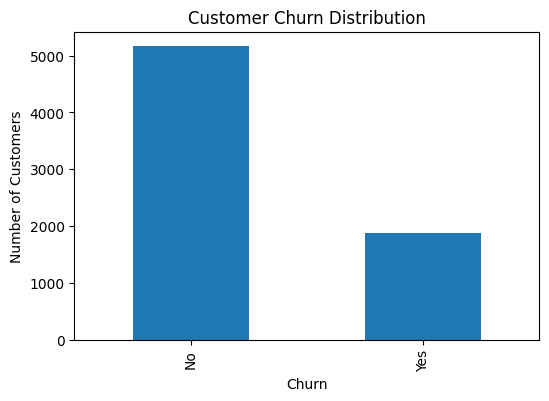

In [28]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Customer Churn Distribution"
)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

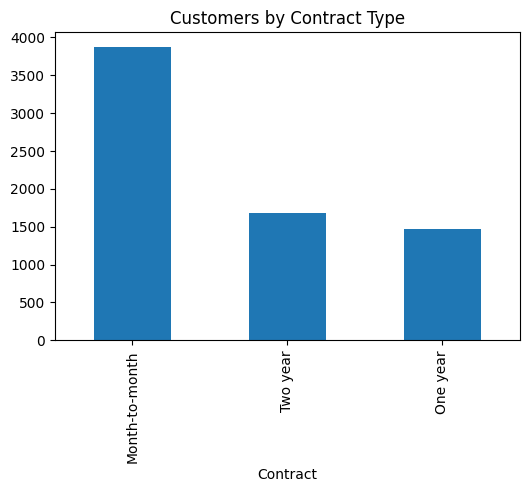

In [29]:
df["Contract"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Customers by Contract Type"
)
plt.show()

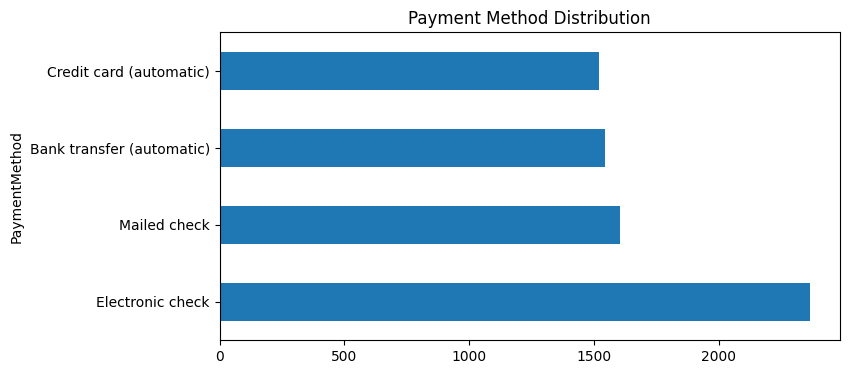

In [30]:
df["PaymentMethod"].value_counts().plot(
    kind="barh",
    figsize=(8,4),
    title="Payment Method Distribution"
)
plt.show()

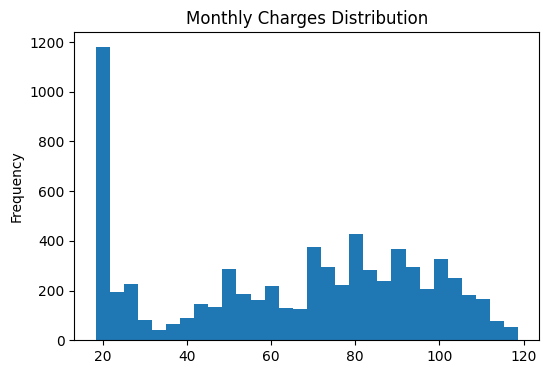

In [31]:
df["MonthlyCharges"].plot(
    kind="hist",
    bins=30,
    figsize=(6,4),
    title="Monthly Charges Distribution"
)
plt.show()

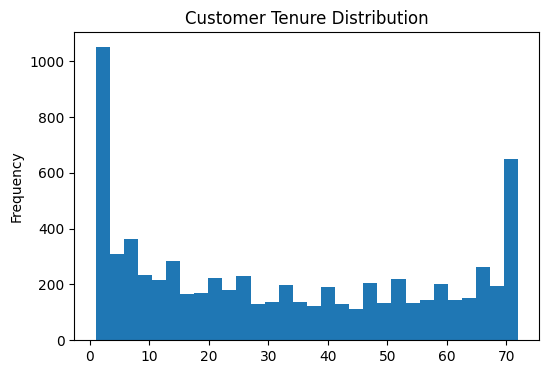

In [32]:
df["tenure"].plot(
    kind="hist",
    bins=30,
    figsize=(6,4),
    title="Customer Tenure Distribution"
)
plt.show()

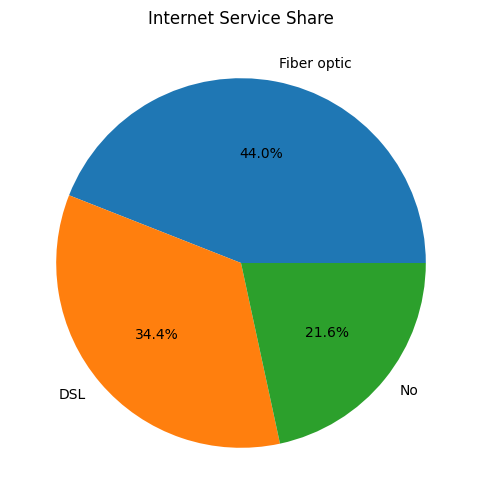

In [33]:
df["InternetService"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Internet Service Share"
)
plt.ylabel("")
plt.show()

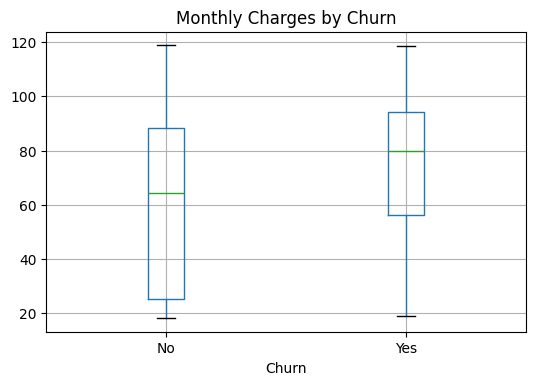

In [34]:
df.boxplot(column="MonthlyCharges", by="Churn", figsize=(6,4))
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.show()

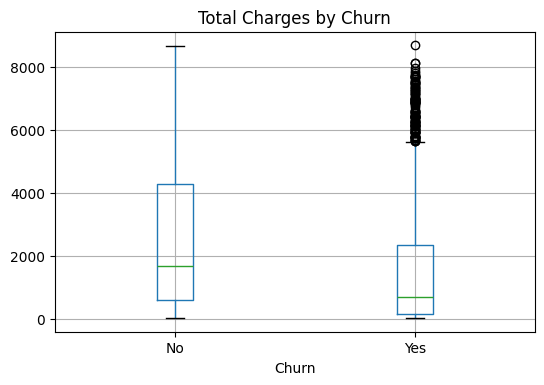

In [35]:
df.boxplot(column="TotalCharges", by="Churn", figsize=(6,4))
plt.title("Total Charges by Churn")
plt.suptitle("")
plt.show()

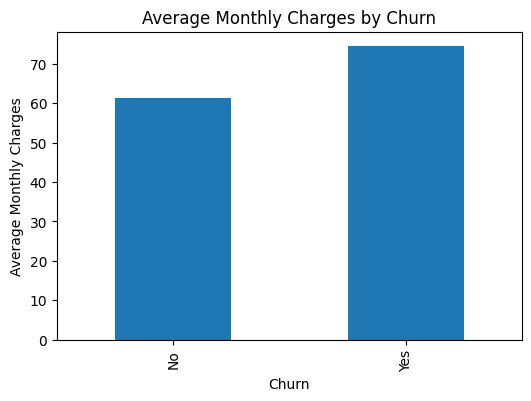

In [36]:
df.groupby("Churn")["MonthlyCharges"].mean().plot(
    kind="bar",
    figsize=(6,4),
    title="Average Monthly Charges by Churn"
)
plt.ylabel("Average Monthly Charges")
plt.show()

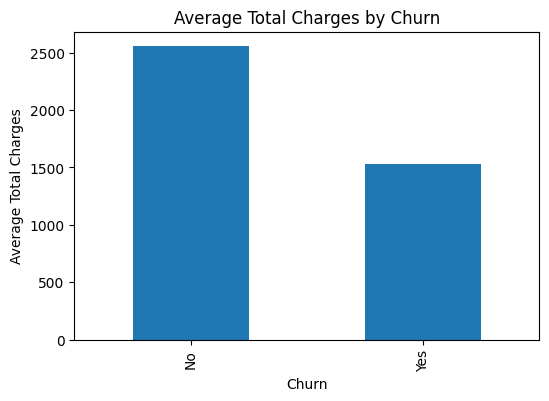

In [37]:
df.groupby("Churn")["TotalCharges"].mean().plot(
    kind="bar",
    figsize=(6,4),
    title="Average Total Charges by Churn"
)
plt.ylabel("Average Total Charges")
plt.show()

In [38]:
df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

In [39]:
df["customerID"].nunique()

7032

In [40]:
# Total Customers
total_customers = len(df)

# Churned Customers
churned_customers = len(df[df["Churn"] == "Yes"])

# Active Customers
active_customers = len(df[df["Churn"] == "No"])

# Churn Rate
churn_rate = round((churned_customers / total_customers) * 100, 2)

# Total Revenue
total_revenue = round(df["TotalCharges"].sum(), 2)

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Active Customers:", active_customers)
print("Churn Rate:", churn_rate, "%")
print("Total Revenue:", total_revenue)

Total Customers: 7032
Churned Customers: 1869
Active Customers: 5163
Churn Rate: 26.58 %
Total Revenue: 16056168.7
